# COE 311K Final Project - Part 1 of 3

Karthik Gunaseelan, EID: kkg745
Emeric Famesc
Project: 2-Person Group

# Section 1: Introduction and Model Selection

For this project, I am modeling a car suspension system as a spring-mass-damper system (Option A). This is a realistic engineering application because car suspensions are designed to reduce vertical motion after the car hits a bump, pothole, or uneven road surface. The system can be modeled as a second-order ordinary differential equation because the motion depends on displacement, velocity, and acceleration.


Governing Second-Order ODE (Format Taken From Claude):

$$m\frac{d^2y}{dt^2} + c\frac{dy}{dt} + ky = 0$$

- m: Vehicle mass supported by one suspension
- c: Damping coefficient 
- k: Spring constant
- y: Position in the vertical direction

Conversion to System of First-Order ODE's:

$$\frac{dy}{dt} = v$$


$$\frac{dv}{dt} = \frac{-cv-ky}{m}$$


- dy/dy = v: Change position in the vertical direction (vertical velocity)
- dv/dt: Change in vertical velocity (vertical acceleration)

# Section 2: Parameter Research and Justification

citations after conlclusion.

# Section 3: Numerical Methods Implementation

Governing Second-Order ODE:

$$m\frac{d^2y}{dt^2} + c\frac{dy}{dt} + ky = 0$$

System of First-Order ODE's:

$$\frac{dy_1}{dt} = y_2$$ $$\frac{dy_2}{dt} = f(t, y_1, y_2)$$

Applied To Spring-Mass-Damper System:

$$\frac{dy}{dt} = v$$ , $$\frac{dv}{dt} = \frac{-cv-ky}{m}$$

In [134]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

m = 300.0 # Mass supported by one suspension (kg)
c = 1500.0 # Damping coefficient (N*s/m)
k = 25000.0 # Spring constant (N/m)
t_start = 0 # Initial time (s)
t_end = 5 # Final time (s)
y_0 = 0.05 # Initial displacement (m)
v_0 = 0.0 # Initial velocity (m/s)
h_values = np.array([0.05, 0.01, 0.005]) # 3 Different Step Sizes

# Function representing the second-order ODE converted to first-order system

def f(t, y, v):
    return -(c / m) * v - (k / m) * y

In [135]:
# Euler's Forward Method

def euler_method(h, m, c, k, t_start, t_end, y_0, v_0):
    
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))
    
    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0
    
    for i in range(1, len(t_values)):
       
        #Current Values
        t_n = t_values[i - 1]
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]
        
        # Euler update equations
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * f(t_n, y_n, v_n)
        
    return t_values, y_values, v_values

In [136]:
# RK4 Method for the system of first-order ODEs

def rk4_method(h, m, c, k, t_start, t_end, y_0, v_0):
    
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))
    
    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0
    
    for i in range(1, len(t_values)):
        
        t_n = t_values[i - 1]
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]
        
        # k1 values
        k1_y = h * v_n
        k1_v = h * f(t_n, y_n, v_n)
        
        # k2 values
        k2_y = h * (v_n + k1_v / 2)
        k2_v = h * f(t_n + h / 2, y_n + k1_y / 2, v_n + k1_v / 2)
        
        # k3 values
        k3_y = h * (v_n + k2_v / 2)
        k3_v = h * f(t_n + h / 2, y_n + k2_y / 2, v_n + k2_v / 2)
        
        # k4 values
        k4_y = h * (v_n + k3_v)
        k4_v = h * f(t_n + h, y_n + k3_y, v_n + k3_v)
        
        # RK4 update equations
        y_values[i] = y_n + (k1_y + 2 * k2_y + 2 * k3_y + k4_y) / 6
        v_values[i] = v_n + (k1_v + 2 * k2_v + 2 * k3_v + k4_v) / 6
        
    return t_values, y_values, v_values

The governing second-order ODE was broken up into two first-order ODE's which were solved by the Euler's Forward Method and RK4 Method.

The first numerical method used was the Euler’s Forward Method. This method uses the current slope of the solution to estimate the next value. At each time step, the displacement is updated using the current velocity, and the velocity is updated using the current acceleration. However, its accuracy depends strongly on the step size, as larger step sizes may lead to higher error or instability.

The second numerical method used was the RK4 Method. RK4 improves accuracy by evalutation the slope at four locations/velocities within each time step respectively, rather than just one slope at the beginning of the interval. As a result, it has higher accuracy than Euler's Method, even with larger step sizes.

# Section 4: Solutions and Comparisons

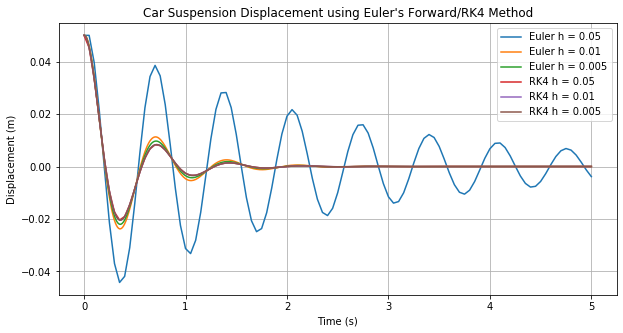

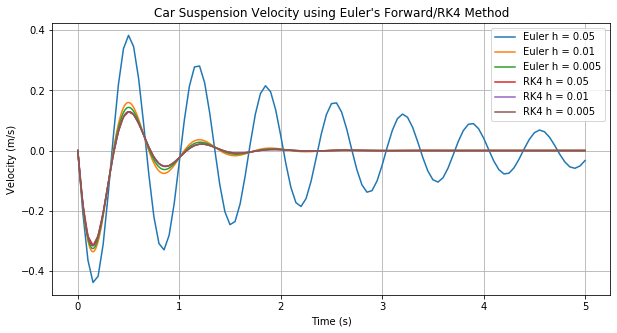

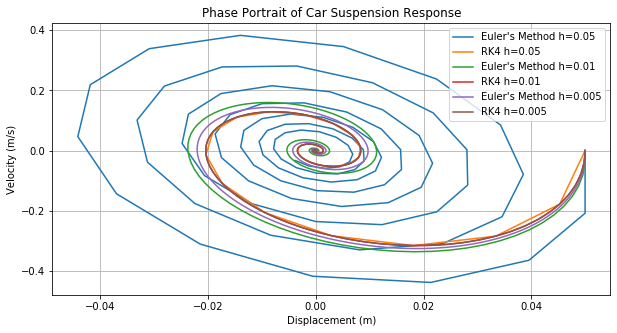

In [137]:
# Plot displacement for both in one graph

plt.figure(figsize=(10, 5))

for h in h_values:
    t_euler, y_euler, v_euler = euler_method(h, m, c, k, t_start, t_end, y_0, v_0)
    plt.plot(t_euler, y_euler, label=f'Euler h = {h}')
    
for h in h_values:
    t_rk4, y_rk4, v_rk4 = rk4_method(h, m, c, k, t_start, t_end, y_0, v_0)
    plt.plot(t_rk4, y_rk4, label=f'RK4 h = {h}')

plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title("Car Suspension Displacement using Euler's Forward/RK4 Method")
plt.legend()
plt.grid(True)
plt.show()

# Plot velocity for both in one graph

plt.figure(figsize=(10, 5))

for h in h_values:
    t_euler, y_euler, v_euler = euler_method(h, m, c, k, t_start, t_end, y_0, v_0)
    plt.plot(t_euler, v_euler, label=f'Euler h = {h}')
    
for h in h_values:
    t_rk4, y_rk4, v_rk4 = rk4_method(h, m, c, k, t_start, t_end, y_0, v_0)
    plt.plot(t_rk4, v_rk4, label=f'RK4 h = {h}')

plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title("Car Suspension Velocity using Euler's Forward/RK4 Method")
plt.legend()
plt.grid(True)
plt.show()

# Phase portrait

plt.figure(figsize=(10, 5))

for h in h_values:
    
    # t,v,y arrays from Euler's Method and RK4
    t_euler, y_euler, v_euler = euler_method(h, m, c, k, t_start, t_end, y_0, v_0)
    t_rk4, y_rk4, v_rk4 = rk4_method(h, m, c, k, t_start, t_end, y_0, v_0)
    
    plt.plot(y_euler, v_euler, label=f'Euler\'s Method h={h}')
    plt.plot(y_rk4, v_rk4, label=f'RK4 h={h}')

plt.xlabel('Displacement (m)')
plt.ylabel('Velocity (m/s)')
plt.title('Phase Portrait of Car Suspension Response')
plt.legend()
plt.grid(True)
plt.show()

The Position vs. Time and Velocity Vs. Time plots show that Euler's Method becomes unstable much faster than RK4 as step size increases. This instability is shown by larger amplitude distortions in Euler's Method and phase shifts when step size is higher, which is unlike RK4 where the plot maintains accurate damped osciallations even at higher step sizes.

# Section 5: Stability Analysis

In the prior section, the numerical solutions for Euler's Method and RK4 become less accurate as step size increases, with Euler's Method diverging faster than RK4.

### Euler's Method
To find the maximum stable step size for Euler's Method, this condition must be satisfied: $$|1+hλ| ≤ 1$$

Since the system in this scenario is underdamped, we can apply $$λ = α±iβ$$ into the previous equation and simplify it to reach the stability condition: $$h<\frac{c}{k}$$

Using the parameters c and k, researched in Section 2, the stability condition for Euler's Method is h<####. Both comparison plots support this since Euler's Method was close to diverging at around h=####, which is near the theoretical limit.

### RK4
To find the maximum stable step size for RK4, we use the stability function (Taylor Series): 
$$R(z) = 1 + z + \frac{z^2}{2} + \frac{z^3}{6} + \frac{z^4}{24}$$ where z = hλ and ∣R(z)∣ ≤ 1

This can be simplified to: $$h≤\frac{1.6}{{\sqrt(\frac{k}{m})}}$$

Using the parameters k and m, researched in Section 2, the stability condition is found to be h<####, which is much higher than that of Euler's Method like we would expect.

When the step size gets larger than the stability condition, the numerical solution becomes unstable. This instability can create distorted and amplified oscillations, which increases with higher step sizes. This creates a situation where trajectories spiral outward in the phase portrait, which show divergence.

### Analytical Solution:

Governing Second-Order ODE:

$$m\frac{d^2y}{dt^2} + c\frac{dy}{dt} + ky = 0$$ Becomes $$\frac{d^2y}{dt^2} + (\frac{c}{m})\frac{dy}{dt} + (\frac{k}{m})y = 0$$

After Solving Using the Characteristic Equation and Initial Condition, Find Analytical Solution:

In [117]:
# Checked Using Claude (CHECK AFTER DOING DATA TO MAKE SURE OF CORRECT FORMULA)

# Analytical solution for underdamped case

alpha = c / (2 * m)
beta_n = np.sqrt(k / m)
beta_d = np.sqrt(beta_n**2 - alpha**2)

C1 = y_0
C2 = (v_0 + alpha * C1) / beta_d

def analytical_solution(t):
    return np.exp(-alpha * t) * (C1 * np.cos(beta_d * t) + C2 * np.sin(beta_d * t))

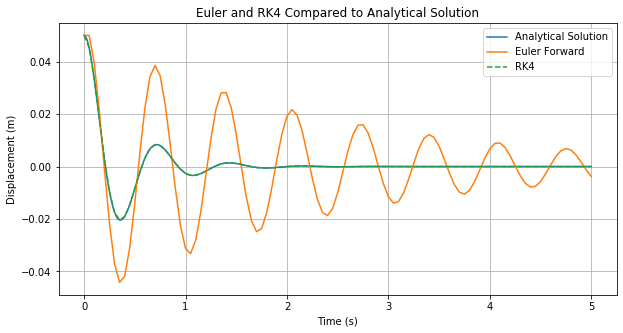

In [118]:
# Plotted analytical solution against Euler and RK4 for one step size

h = 0.05

t_euler, y_euler, v_euler = euler_method(h, m, c, k, t_start, t_end, y_0, v_0)
t_rk4, y_rk4, v_rk4 = rk4_method(h, m, c, k, t_start, t_end, y_0, v_0)

t_exact = np.linspace(t_start, t_end, 1000)
y_exact = analytical_solution(t_exact)

plt.figure(figsize=(10, 5))
plt.plot(t_exact, y_exact, label='Analytical Solution')
plt.plot(t_euler, y_euler, label='Euler Forward')
plt.plot(t_rk4, y_rk4, label='RK4', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Euler and RK4 Compared to Analytical Solution')
plt.legend()
plt.grid(True)
plt.show()

In [119]:
# Function to calculate average absolute error

def calculate_average_error(t_values, y_values):
    
    y_exact = analytical_solution(t_values)
    error = np.abs(y_exact - y_values)
    avg_error = np.mean(error)
    
    return avg_error

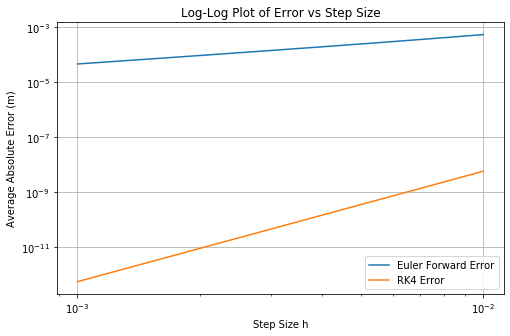

Euler Estimated Convergence Slope (Convergence Rate): 1.068485253719011
RK4 Estimated Convergence Slope (Convergence): 4.0559285587767215


In [128]:
# Error vs step size for Euler and RK4

error_h_values = np.linspace(0.001, 0.01, 30)

euler_errors = np.zeros(len(error_h_values))
rk4_errors = np.zeros(len(error_h_values))

for index, h in enumerate(error_h_values):
    
    t_euler, y_euler, v_euler = euler_method(h, m, c, k, t_start, t_end, y_0, v_0)
    t_rk4, y_rk4, v_rk4 = rk4_method(h, m, c, k, t_start, t_end, y_0, v_0)
    
    euler_errors[index] = calculate_average_error(t_euler, y_euler)
    rk4_errors[index] = calculate_average_error(t_rk4, y_rk4)

# Log-log plot of error vs step size

plt.figure(figsize=(8, 5))
plt.loglog(error_h_values, euler_errors, '-', label='Euler Forward Error')
plt.loglog(error_h_values, rk4_errors, '-', label='RK4 Error')
plt.xlabel('Step Size h')
plt.ylabel('Average Absolute Error (m)')
plt.title('Log-Log Plot of Error vs Step Size')
plt.legend()
plt.grid(True)
plt.show()

# Estimate convergence slopes

euler_slope = (np.log(euler_errors[-1]) - np.log(euler_errors[0])) / (np.log(error_h_values[-1]) - np.log(error_h_values[0]))
rK4_slope = (np.log(rk4_errors[-1]) - np.log(rk4_errors[0])) / (np.log(error_h_values[-1]) - np.log(error_h_values[0]))

print("Euler Estimated Convergence Slope (Convergence Rate):", euler_slope)
print("RK4 Estimated Convergence Slope (Convergence):", rk4_slope)

Numerical instability often leads to unrealistic results because the numerical solution no longer follows the governing differential equation. Since this is a damped system, the total mechanical energy should decrease over time, resulting in osciallations that graudually fade. When instability occurs, the numerical method may introduce artificial energy into the system, causing the oscillations to grow rather than decay. For a car suspension model, this would mean the vehicle mass gains motion without any external input, which violates the physics of a spring-mass-damper system.

# Section 6: Conclusion

For this application, RK4 was a better method in terms of both stability and accuracy.Euler's method lost accuracy quickly as the step size increase, while RK4 continued to produce stable and reliable solutions at larger step sizes. As a result, RK4 was able to capture the damping behavior of the system much more effectively than Euler's Method. 

RK4 has a time complexity of O(n^4), while Euler's Method has a time complexity of O(n), making RK4 more computationally costly. Even though RK4 is more expensive per iteration, however, its larger stable step-size range often means fewer total steps are needed. Because of that, RK4 can be computationally cheaper overall to reach a certain accuracy target.

In practice, Euler’s Method is most useful for short simulations where very small step sizes can be used. For longer simulations or cases where the response must closely match the real system, RK4 is the better option because it is more dependable and accurate. One major takeaway from this project is that higher-order methods are often essential when solving realistic engineering dynamics problems.

### Citations (Listed in Paranthesis When Used):
- Claude: https://claude.ai/new